<a href="https://colab.research.google.com/github/JulTob/Data/blob/main/P4_Analisis-Wind.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 4

## ⚠️ IMPORTANTE ⚠️
- En el menú superior seleccionar: `Runtime` ⇒ `Change Runtime Type` ⇲ `Runtime Type`⇒ `R`


Confirmamos que funcione R

In [24]:
R.version.string

[1] "R version 4.5.2 (2025-10-31)"

Para asegurar reproducibilidad se ha hosteado el archivo csv en GitHub.

In [25]:
install.packages("readr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [74]:
library(readr)
url <- "https://raw.githubusercontent.com/JulTob/Data/main/CSVs/temperatura.csv"
temperatura_df <- read_delim(url, delim = ";")
head(temperatura_df)

Rows: 23 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ";"
chr (2): City, Area
dbl (4): Annual, Amplitude, Latitude, Longitude

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


City,Annual,Amplitude,Latitude,Longitude,Area
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Amsterdam,9.9,14.6,52.2,4.5,West
Athens,17.8,18.3,37.6,23.5,South
Berlin,9.1,18.5,52.3,13.2,West
Brussels,10.3,14.4,50.5,4.2,West
Budapest,10.9,23.1,47.3,19.0,East
Copenhagen,7.8,17.5,55.4,12.3,North


# Ejercicio 1:

In [28]:
install.packages("nasaweather")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [51]:
library(nasaweather)
data(storms)
head(storms)

name,year,month,day,hour,lat,long,status,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter
<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<int>,<int>,<int>,<int>
Amy,1975,6,27,0,27.5,-79.0,tropical depression,NA,25,1013,NA,NA
Amy,1975,6,27,6,28.5,-79.0,tropical depression,NA,25,1013,NA,NA
Amy,1975,6,27,12,29.5,-79.0,tropical depression,NA,25,1013,NA,NA
Amy,1975,6,27,18,30.5,-79.0,tropical depression,NA,25,1013,NA,NA
Amy,1975,6,28,0,31.5,-78.8,tropical depression,NA,25,1012,NA,NA
Amy,1975,6,28,6,32.4,-78.7,tropical depression,NA,25,1012,NA,NA


In [30]:
# 1 mbar = 100 Pascales [Pa] = [N]/[m2]
# 1 nudo = 0.514444 metros por segundo (m/s)

storms_si <- storms
    #-- Storms con unidades del SI

storms_si$pressure_pa <- storms_si$pressure * 100
storms_si$wind_ms <- storms_si$wind * 0.514444

# Display
head(storms_si)

name,year,month,day,hour,lat,long,pressure,wind,type,seasday,category,pressure_pa,wind_ms
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Allison,1995,6,3,0,17.4,-84.3,1005,30,Tropical Depression,3,-1,100500,15.43332
Allison,1995,6,3,6,18.3,-84.9,1004,30,Tropical Depression,3,-1,100400,15.43332
Allison,1995,6,3,12,19.3,-85.7,1003,35,Tropical Storm,3,0,100300,18.00554
Allison,1995,6,3,18,20.6,-85.8,1001,40,Tropical Storm,3,0,100100,20.57776
Allison,1995,6,4,0,22.0,-86.0,997,50,Tropical Storm,4,0,99700,25.72220
Allison,1995,6,4,6,23.3,-86.3,995,60,Tropical Storm,4,0,99500,30.86664


### Media y Mediana

In [31]:
# Medidas centrales de tendencia
mean_wind_ms <- mean(storms_si$wind_ms)
median_wind_ms <- median(storms_si$wind_ms)

cat("Mean of wind_ms:", mean_wind_ms, "\n")
cat("Median of wind_ms:", median_wind_ms, "\n")


Mean of wind_ms: 28.13149 
Median of wind_ms: 25.7222 


# Moda

Lo más natural es dividir el rango entre el máximo y mínimo valor, dividirlo en $Log(N)$ medidas (siendo N el Nº total de medidas). Se puede realizar el histograma de esta tabla, pero para obtener la moda swolo necesitamos el máximo.

Un detalle a considerar es el tamaño de la base del logaritmo. Como norma general, base 2 tiene ciertas propiedades de interés (entropia, digitalización...) pero sobretodo tiene la bondad de referirse a 'divisiones por la mitad'. Además de ser la representación más granular.

In [32]:
# Calculate the range of wind_ms
min_wind_ms <- min(storms_si$wind_ms, na.rm = TRUE)
max_wind_ms <- max(storms_si$wind_ms, na.rm = TRUE)

N <- length(storms_si$wind_ms)
num_divisions <- ceiling(log2(N))
    #-- Base 2 es la más detallada

bins <- seq(
    min_wind_ms,
    max_wind_ms,
    length.out = num_divisions)

wind_ms_binned <- cut(
    storms_si$wind_ms,
    breaks = bins,
    include.lowest = TRUE)

# Tabla de frecuencia
wind_ms_freq <- table(wind_ms_binned)

# La agrupación modal
mode_bin_index <- which.max(wind_ms_freq)
mode_bin <- names(mode_bin_index)


cat("Nº de Divisiones:", num_divisions, "\n")
head(wind_ms_freq)
cat("Tramo de Moda de wind_ms:", mode_bin, "\n")


Nº de Divisiones: 12 


wind_ms_binned
[7.72,14.3] (14.3,20.8] (20.8,27.4] (27.4,33.9] (33.9,40.5]   (40.5,47] 
        293         791         436         479         255         231 

Tramo de Moda de wind_ms: (14.3,20.8] 


Ahora podemos calcular la marca del intervalo (bin).

In [33]:
min_bin <- bins[mode_bin_index]
max_bin <- bins[mode_bin_index + 1]

cat("Min de la bin modal:", min_bin, "\n")
cat("Max de la bin modal:", max_bin, "\n")

mode_wind_ms = (min_bin + max_bin)/2
cat("Valor de marca de la moda:", mode_wind_ms)

Min de la bin modal: 14.26413 
Max de la bin modal: 20.8116 
Valor de marca de la moda: 17.53786

Podemos aprovechar la tabla para representar los datos.

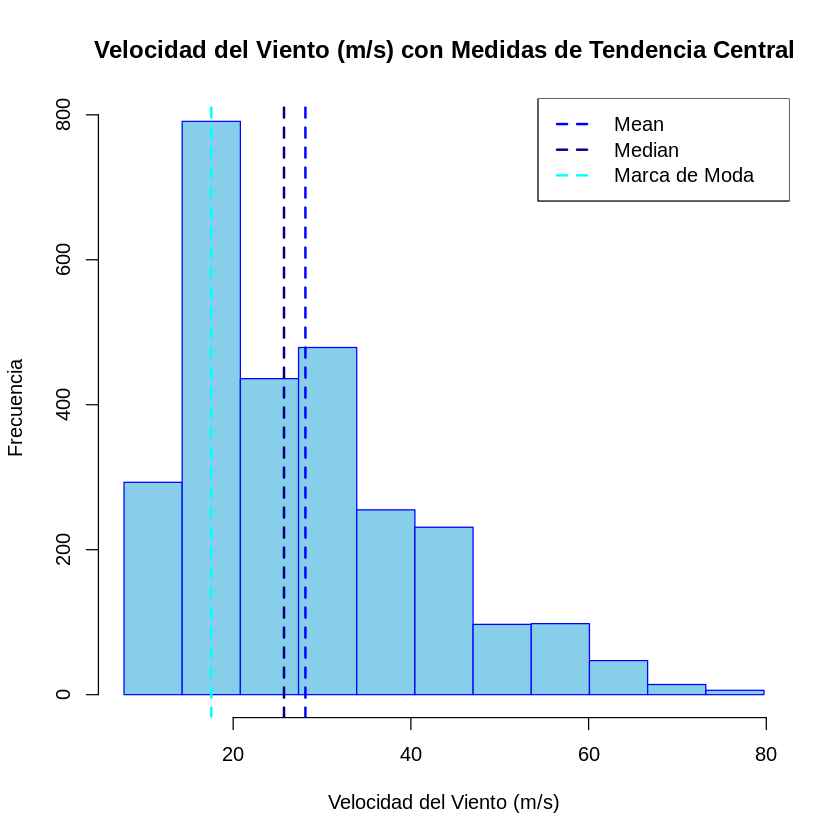

In [34]:
hist(storms_si$wind_ms, breaks = bins, main = "Velocidad del Viento (m/s) con Medidas de Tendencia Central", xlab = "Velocidad del Viento (m/s)", ylab = "Frecuencia", col = "skyblue", border = "blue")

# Add vertical lines for mean, median, and mean within the modal bin
abline(v = mean_wind_ms, col = "blue", lty = 2, lwd = 2)
abline(v = median_wind_ms, col = "navy", lty = 2, lwd = 2)
abline(v = mode_wind_ms, col = "cyan", lty = 2, lwd = 2)

# Add a legend
legend("topright", legend = c("Mean", "Median", "Marca de Moda"), col = c("blue", "navy", "cyan"), lty = 2, lwd = 2)

In [ ]:
install.packages("vioplot")

Vemos gracias al Log2 que se trata de una distribución más o menos Parettoide.

Yo particularmente entiendo mejor el uso de kmh que ms. Podemos convertir fácilmente estas medidas de tendencia para entender mejor estas medidas de tendencia.

In [35]:
# Conversion factor from m/s to km/h
ms_to_kmh <- 3.6

# Convert mean, median, and mean in modal bin to km/h
mean_wind_kmh <- mean_wind_ms * ms_to_kmh
median_wind_kmh <- median_wind_ms * ms_to_kmh
mode_wind_kmh <- mode_wind_ms * ms_to_kmh

# Display the results
cat("Mean of wind speed (km/h):", mean_wind_kmh, "\n")
cat("Median of wind speed (km/h):", median_wind_kmh, "\n")
cat("Mean in modal bin of wind speed (km/h):", mode_wind_kmh, "\n")

Mean of wind speed (km/h): 101.2734 
Median of wind speed (km/h): 92.59992 
Mean in modal bin of wind speed (km/h): 63.13631 


Esto permite entender que de media el viento en una tormenta alcanza los 100 kilometros por hora, pero la observación más medida será de poco más de 60 kilometros por hora.

Esto significa, por ejemplo, que el impacto por un objeto llevado por el viento es comparable a que se lancen desde un coche en carretera comarcal para el grueso de objetos, pero la mayoría sería equivalentes a que lo lance un coche en autovía. El efecto a la larga seria que cada objeto ha sido lanzado a una velocidad de autovia de 100 kmh.

 <!--< Se nota que trabajo en seguros? >-->

### Calcula el primer y tercer cuartil e interpreta los resultados.

In [36]:
# Calculate the first and third quartiles of wind_ms
quartiles_wind_ms <- quantile(storms_si$wind_ms, probs = c(0.25, 0.75), na.rm = TRUE)

# Extract the first and third quartiles
q1_wind_ms <- quartiles_wind_ms[1]
q3_wind_ms <- quartiles_wind_ms[2]

cat("Primer Quartil (Q1) de wind_ms:", q1_wind_ms, "\n")
cat("Tercer Quartil (Q3) de wind_ms:", q3_wind_ms, "\n")

Primer Quartil (Q1) de wind_ms: 18.00554 
Tercer Quartil (Q3) de wind_ms: 36.01108 


### Calcula P5 y P80 en interpreta los resultados

In [37]:
# Calculate the 5th and 80th percentiles of wind_ms
percentiles_wind_ms <- quantile(storms_si$wind_ms, probs = c(0.05, 0.80), na.rm = TRUE)

# Extract the 5th and 80th percentiles
p5_wind_ms <- percentiles_wind_ms[1]
p80_wind_ms <- percentiles_wind_ms[2]

cat("5º Percentil (P5) de wind_ms:", p5_wind_ms, "\n")
cat("80º Percentil (P80) de wind_ms:", p80_wind_ms, "\n")

5º Percentil (P5) de wind_ms: 12.8611 
80º Percentil (P80) de wind_ms: 38.5833 


### d) Calcula el rango y el rango intercuartílico.

In [38]:
# Rango de wind_ms
range_wind_ms <- max(storms_si$wind_ms, na.rm = TRUE) - min(storms_si$wind_ms, na.rm = TRUE)

# Rango Interquartil(IQR) de wind_ms
# Ya tenemos Q1 y Q3
iqr_wind_ms <- q3_wind_ms - q1_wind_ms

cat("Rango de wind_ms:", range_wind_ms, "\n")
cat("Rango Interquartil (IQR) de wind_ms:", iqr_wind_ms, "\n")

Rango de wind_ms: 72.02216 
Rango Interquartil (IQR) de wind_ms: 18.00554 


### Calcula la desviación media y la desviación media respecto de la mediana.

In [39]:
# Calculate the Mean Absolute Deviation (deviation from the mean)
mad_mean_wind_ms <- mean(abs(storms_si$wind_ms - mean_wind_ms), na.rm = TRUE)

# Calculate the Mean Absolute Deviation from the Median
mad_median_wind_ms <- mean(abs(storms_si$wind_ms - median_wind_ms), na.rm = TRUE)

cat("Mean Absolute Deviation (from Mean) of wind_ms:", mad_mean_wind_ms, "\n")
cat("Mean Absolute Deviation (from Median) of wind_ms:", mad_median_wind_ms, "\n")

Mean Absolute Deviation (from Mean) of wind_ms: 10.76965 
Mean Absolute Deviation (from Median) of wind_ms: 10.51267 


### Calcula la varianza y desviación típica

In [40]:
# Calculate the variance of wind_ms
variance_wind_ms <- var(storms_si$wind_ms, na.rm = TRUE)

# Calculate the standard deviation of wind_ms
sd_wind_ms <- sd(storms_si$wind_ms, na.rm = TRUE)

cat("Variance of wind_ms:", variance_wind_ms, "\n")
cat("Standard Deviation of wind_ms:", sd_wind_ms, "\n")

Variance of wind_ms: 176.8262 
Standard Deviation of wind_ms: 13.2976 


### Calcula el coeficiente de variación de Pearson e Intercuartílico.
¿Los datos están muy
dispersos?

In [41]:
# Calculate Pearson's Coefficient of Variation
# CV_Pearson = (Standard Deviation / Mean) * 100
cv_pearson <- (sd_wind_ms / mean_wind_ms) * 100

# Calculate the Interquartile Coefficient of Variation
# CV_IQR = ((Q3 - Q1) / (Q3 + Q1)) * 100
cv_iqr <- ((q3_wind_ms - q1_wind_ms) / (q3_wind_ms + q1_wind_ms)) * 100

cat("Pearson's Coefficient of Variation:", cv_pearson, "%\n")
cat("Interquartile Coefficient of Variation:", cv_iqr, "%\n")

Pearson's Coefficient of Variation: 47.26945 %
Interquartile Coefficient of Variation: 33.33333 %


### h) Valora la forma de la distribución de esta variable (asimetría y curtosis).

In [42]:
# Calculate skewness manually
n <- length(storms_si$wind_ms)
mean_wind_ms <- mean(storms_si$wind_ms, na.rm = TRUE)
sd_wind_ms <- sd(storms_si$wind_ms, na.rm = TRUE)

skewness_manual <- (1/n) * sum(((storms_si$wind_ms - mean_wind_ms) / sd_wind_ms)^3, na.rm = TRUE)

cat("Manual Skewness of wind_ms:", skewness_manual, "\n")

Manual Skewness of wind_ms: 0.8981482 


In [43]:
# Calculate kurtosis (excess kurtosis) manually
n <- length(storms_si$wind_ms)
mean_wind_ms <- mean(storms_si$wind_ms, na.rm = TRUE)
sd_wind_ms <- sd(storms_si$wind_ms, na.rm = TRUE)

kurtosis_manual <- ((1/n) * sum(((storms_si$wind_ms - mean_wind_ms) / sd_wind_ms)^4, na.rm = TRUE)) - 3

cat("Manual Kurtosis (Excess) of wind_ms:", kurtosis_manual, "\n")

Manual Kurtosis (Excess) of wind_ms: 0.3246446 


### Realiza un histograma y el gráfico de cajas de la variable wind e interpreta los gráficos.

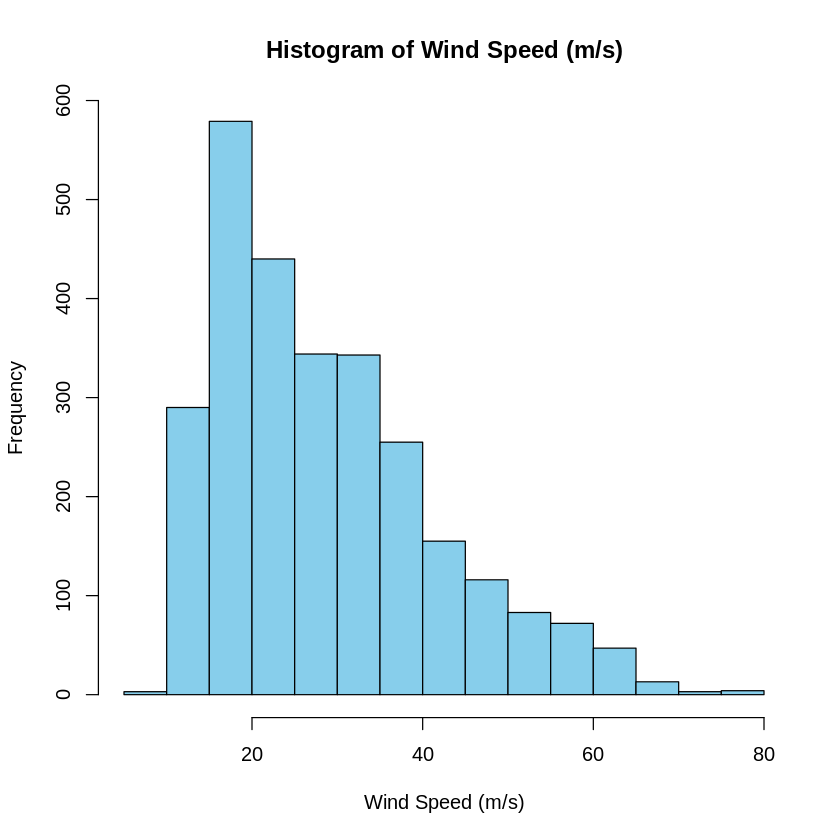

In [44]:
# Create a histogram of the 'wind' variable
hist(storms_si$wind_ms, main = "Histogram of Wind Speed (m/s)", xlab = "Wind Speed (m/s)", ylab = "Frequency", col = "skyblue", border = "black")

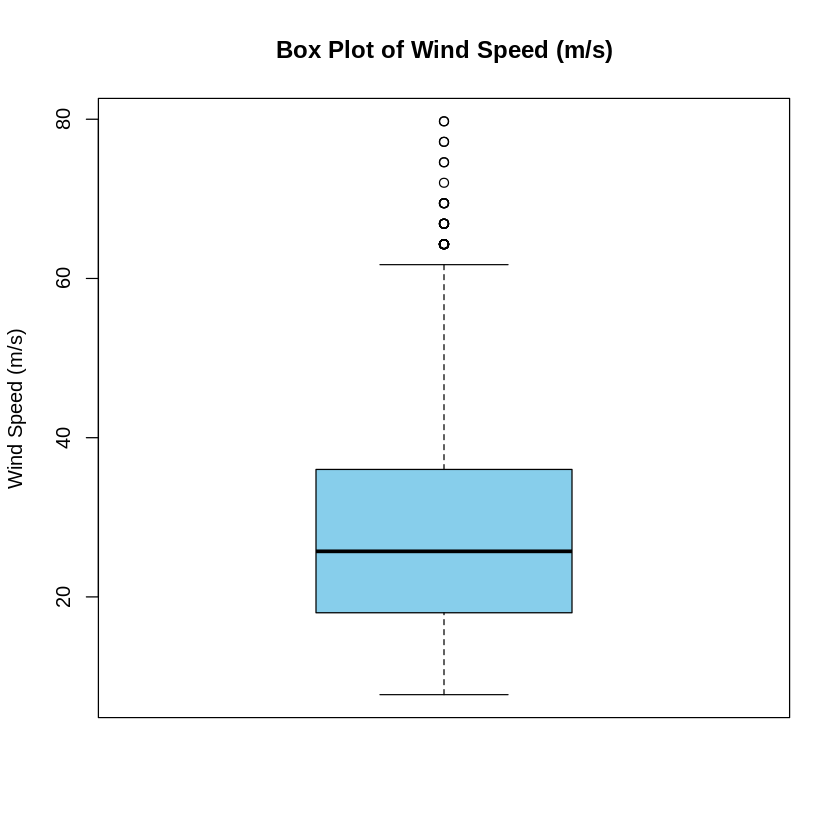

In [45]:
# Create a box plot of the 'wind' variable
boxplot(storms_si$wind_ms, main = "Box Plot of Wind Speed (m/s)", ylab = "Wind Speed (m/s)", col = "skyblue", border = "black")

### Realiza algún resumen conjunto con las opciones que nos proporcionan la función `summary( )` y las librerías `dplyr` y `psych`

In [50]:
install.packages("psych")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Let's start with the `summary()` function, which provides a basic statistical summary of each column in the data frame.

In [46]:
# Summary using the base R summary() function
summary(storms_si)

     name                year          month             day       
 Length:2747        Min.   :1995   Min.   : 6.000   Min.   : 1.00  
 Class :character   1st Qu.:1995   1st Qu.: 8.000   1st Qu.: 9.00  
 Mode  :character   Median :1997   Median : 9.000   Median :18.00  
                    Mean   :1997   Mean   : 8.803   Mean   :16.98  
                    3rd Qu.:1999   3rd Qu.:10.000   3rd Qu.:25.00  
                    Max.   :2000   Max.   :12.000   Max.   :31.00  
      hour             lat             long            pressure     
 Min.   : 0.000   Min.   : 8.30   Min.   :-107.30   Min.   : 905.0  
 1st Qu.: 3.500   1st Qu.:17.25   1st Qu.: -77.60   1st Qu.: 980.0  
 Median :12.000   Median :25.00   Median : -60.90   Median : 995.0  
 Mean   : 9.057   Mean   :26.67   Mean   : -60.87   Mean   : 989.8  
 3rd Qu.:18.000   3rd Qu.:33.90   3rd Qu.: -45.80   3rd Qu.:1004.0  
 Max.   :18.000   Max.   :70.70   Max.   :   1.00   Max.   :1019.0  
      wind            type              s

Now, let's use the `dplyr` package to calculate some custom summary statistics. We'll group by storm type and calculate the mean and median wind speed.

In [47]:
# Install and load the dplyr package if not already installed
# install.packages("dplyr")
library(dplyr)

# Group by type and summarize wind_ms
storms_summary_dplyr <- storms_si %>%
  group_by(type) %>%
  summarise(
    mean_wind_ms = mean(wind_ms, na.rm = TRUE),
    median_wind_ms = median(wind_ms, na.rm = TRUE)
  )

# Display the summary
print(storms_summary_dplyr)


Attaching package: ‘dplyr’


The following object is masked _by_ ‘.GlobalEnv’:

    storms


The following object is masked from ‘package:nasaweather’:

    storms


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# A tibble: 4 × 3
  type                mean_wind_ms median_wind_ms
  <chr>                      <dbl>          <dbl>
1 Extratropical               20.6           20.6
2 Hurricane                   43.6           41.2
3 Tropical Depression         14.1           15.4
4 Tropical Storm              24.3           23.1


Finally, let's use the `psych` package to get a more comprehensive descriptive summary, including measures of central tendency, dispersion, and shape.

In [52]:
# Install and load the psych package if not already installed
# install.packages("psych")
library(psych)

# Get descriptive statistics using the describe() function from psych
describe(storms_si$wind_ms)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X1,1,2747,28.13149,13.2976,25.7222,26.68605,15.25429,7.71666,79.73882,72.02216,0.8981482,0.3246446,0.2537137


------------

# Ejercicio 2

Los ingresos anuales (en miles de dólares) de los trabajadores de una empresa son los
siguientes:

In [53]:
ingresos = c(5, 6, 5, 7, 5, 6, 5, 8, 10, 12, 15, 18, 25, 5, 7, 5, 10, 15, 20, 32, 35, 40, 6, 12, 14, 100, 115, 220, 300)

In [54]:
ingresos

[1]   5   6   5   7   5   6   5   8  10  12  15  18  25   5   7   5  10  15  20
[20]  32  35  40   6  12  14 100 115 220 300

### a) Calcula el índice de Gini para medir la desigualdad en esta distribución de ingresos.
Interpreta el resultado obtenido.

In [56]:
# Function to calculate the Gini index
gini <- function(x) {
  n <- length(x)
  sum(sort(x) * 1:n) / sum(x) / n - (n + 1) / 2 / n
}

# Calculate the Gini index for the 'ingresos' data
gini_index <- gini(ingresos)

# Print the Gini index
cat("El Índice de Gini para los ingresos es:", gini_index, "\n")

# Interpret the result
if (gini_index < 0.2) {
  cat("Interpretación: La desigualdad de ingresos es muy baja.\n")
} else if (gini_index < 0.3) {
  cat("Interpretación: La desigualdad de ingresos es baja.\n")
} else if (gini_index < 0.4) {
  cat("Interpretación: La desigualdad de ingresos es moderada.\n")
} else if (gini_index < 0.5) {
  cat("Interpretación: La desigualdad de ingresos es relativamente alta.\n")
} else {
  cat("Interpretación: La desigualdad de ingresos es alta.\n")
}

El Índice de Gini para los ingresos es: 0.3390859 
Interpretación: La desigualdad de ingresos es moderada.


### b) Describe cómo se distribuyen los ingresos en función del porcentaje de los trabajadores.

In [57]:
# Sort the income data in ascending order
ingresos_sorted <- sort(ingresos)

# Calculate the cumulative percentage of workers and income
n <- length(ingresos_sorted)
percent_workers <- (1:n) / n * 100
cumulative_income <- cumsum(ingresos_sorted)
percent_income <- (cumulative_income / sum(ingresos_sorted)) * 100

# Create a data frame for easier viewing
income_distribution <- data.frame(
  Worker_Percentile = percent_workers,
  Income = ingresos_sorted,
  Cumulative_Income_Percent = percent_income
)

# Display the income distribution
print(income_distribution)

# You can also look at specific percentiles
cat("\nIncome at specific percentiles:\n")
print(quantile(ingresos, probs = c(0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99)))

   Worker_Percentile Income Cumulative_Income_Percent
1           3.448276      5                 0.4703669
2           6.896552      5                 0.9407338
3          10.344828      5                 1.4111007
4          13.793103      5                 1.8814675
5          17.241379      5                 2.3518344
6          20.689655      5                 2.8222013
7          24.137931      6                 3.3866416
8          27.586207      6                 3.9510818
9          31.034483      6                 4.5155221
10         34.482759      7                 5.1740357
11         37.931034      7                 5.8325494
12         41.379310      8                 6.5851364
13         44.827586     10                 7.5258702
14         48.275862     10                 8.4666040
15         51.724138     12                 9.5954845
16         55.172414     12                10.7243650
17         58.620690     14                12.0413923
18         62.068966     15 

### c) Traza la Curva de Lorenz. Interpreta el resultado obtenido.

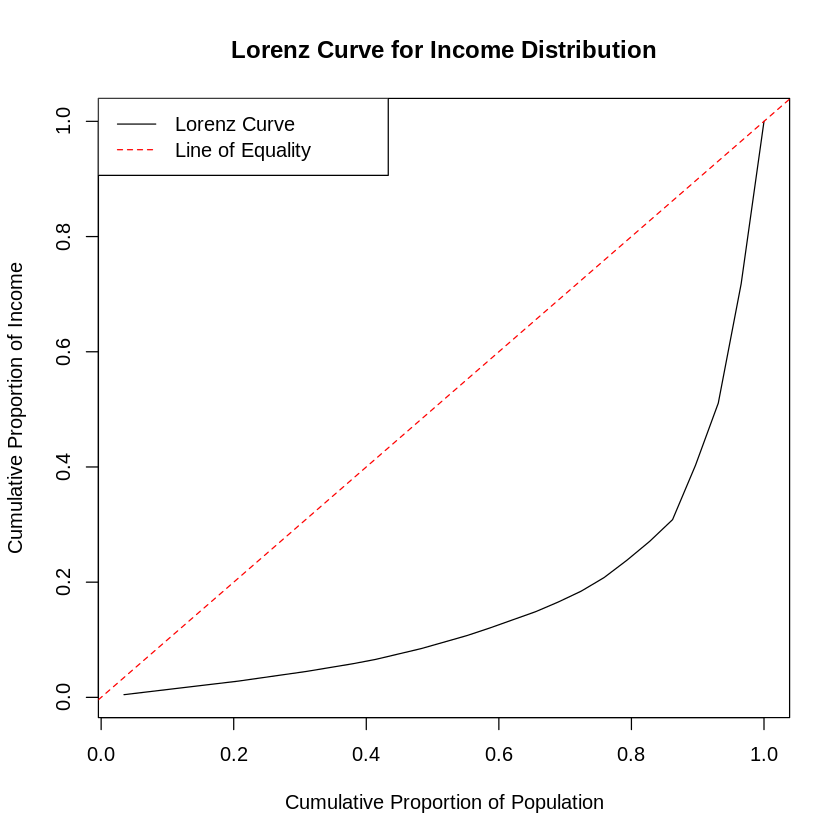

In [58]:
# Calculate cumulative proportion of income and population
ingresos_sorted <- sort(ingresos)
cumulative_income_prop <- cumsum(ingresos_sorted) / sum(ingresos_sorted)
cumulative_population_prop <- (1:length(ingresos_sorted)) / length(ingresos_sorted)

# Plot the Lorenz Curve
plot(cumulative_population_prop, cumulative_income_prop,
     type = "l",
     xlab = "Cumulative Proportion of Population",
     ylab = "Cumulative Proportion of Income",
     main = "Lorenz Curve for Income Distribution")

# Add the line of perfect equality
abline(0, 1, col = "red", lty = 2)

# Add a legend
legend("topleft", legend = c("Lorenz Curve", "Line of Equality"), col = c("black", "red"), lty = c(1, 2))

------

# Ejercicio 3:

En este ejercicio se va a realizar un resumen de los datos correspondiente al dataset
“gapminder” de la librería que lleva su nombre.

### Visualiza los 5 primeros registros de la base de datos.

In [62]:
# Install and load the gapminder package if not already installed
install.packages("gapminder")
library(gapminder)

# Display the first 5 rows of the gapminder dataset
head(gapminder, 5)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



country,continent,year,lifeExp,pop,gdpPercap
<fct>,<fct>,<int>,<dbl>,<int>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453
Afghanistan,Asia,1957,30.332,9240934,820.8530
Afghanistan,Asia,1962,31.997,10267083,853.1007
Afghanistan,Asia,1967,34.020,11537966,836.1971
Afghanistan,Asia,1972,36.088,13079460,739.9811


Muestra el número de filas y de columnas del dataset, así como el nombre de las variables
y su tipología.

In [66]:
# Number of rows and columns
cat("Number of rows and columns:\n", dim(gapminder))

# Names of the variables
cat("\nVariable names:\n", colnames(gapminder))

# Tipology of the variables
cat("\nVariable types:\n", str(gapminder))

Number of rows and columns:
 1704 6
Variable names:
 country continent year lifeExp pop gdpPercaptibble [1,704 × 6] (S3: tbl_df/tbl/data.frame)
 $ country  : Factor w/ 142 levels "Afghanistan",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ continent: Factor w/ 5 levels "Africa","Americas",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ year     : int [1:1704] 1952 1957 1962 1967 1972 1977 1982 1987 1992 1997 ...
 $ lifeExp  : num [1:1704] 28.8 30.3 32 34 36.1 ...
 $ pop      : int [1:1704] 8425333 9240934 10267083 11537966 13079460 14880372 12881816 13867957 16317921 22227415 ...
 $ gdpPercap: num [1:1704] 779 821 853 836 740 ...

Variable types:


### Filtrar todos los datos que sean de Perú del año 2002 y selecciona la variable país, año, esperanza de vida y población. ¿Qué población había en Perú en 2002? ¿Cuál fue su esperanza de vida?

In [67]:
# Filter the data for Peru in 2002 and select the desired columns
peru_2002_data <- gapminder %>%
  filter(country == "Peru", year == 2002) %>%
  select(country, year, lifeExp, pop)

# Display the filtered data
print(peru_2002_data)

# Extract and display the population and life expectancy for Peru in 2002
peru_2002_pop <- peru_2002_data$pop
peru_2002_lifeExp <- peru_2002_data$lifeExp

cat("\nPoblación de Perú en 2002:", peru_2002_pop, "\n")
cat("Esperanza de vida en Perú en 2002:", peru_2002_lifeExp, "\n")

# A tibble: 1 × 4
  country  year lifeExp      pop
  <fct>   <int>   <dbl>    <int>
1 Peru     2002    69.9 26769436

Población de Perú en 2002: 26769436 
Esperanza de vida en Perú en 2002: 69.906 


####  Calcula la media, la desviación típica, los cuartiles, el rango intercuartílico, el mínimo, el máximo, desviación media, la desviación media respecto de la mediana, varianza, desviación típica, coeficiente de variación, asimetría y curtosis para la variable lifeExp en el año 2007 en cada continente.

¿Qué continente tuvo, en 2007, una mayor esperanza de
vida?

¿Qué continente tuvo, en 2007, una menor esperanza de vida?

¿En qué continente,
en 2007, tuvo una mayor variabilidad en la esperanza de vida? ¿En qué continente(s) la
media ofreció un valor más representativo de la realidad?

# Task
Analyze the `lifeExp` variable in the `gapminder` dataset for the year 2007, grouped by continent. Calculate the mean, standard deviation, quartiles, interquartile range, minimum, maximum, mean absolute deviation from the mean, mean absolute deviation from the median, variance, coefficient of variation, skewness, and kurtosis for each continent. Based on these statistics, identify the continent with the highest and lowest mean life expectancy, the continent with the highest variability in life expectancy, and the continent(s) where the mean is the most representative measure of the central tendency.

## Filter data

### Subtask:
Filter the `gapminder` dataset to include only the data from the year 2007.


**Reasoning**:
Filter the gapminder dataset for the year 2007 using dplyr and store it in a new variable.



In [68]:
library(dplyr)

# Filter the gapminder dataset for the year 2007
gapminder_2007 <- gapminder %>%
  filter(year == 2007)

# Display the first few rows of the filtered dataframe
head(gapminder_2007)

country,continent,year,lifeExp,pop,gdpPercap
<fct>,<fct>,<int>,<dbl>,<int>,<dbl>
Afghanistan,Asia,2007,43.828,31889923,974.5803
Albania,Europe,2007,76.423,3600523,5937.0295
Algeria,Africa,2007,72.301,33333216,6223.3675
Angola,Africa,2007,42.731,12420476,4797.2313
Argentina,Americas,2007,75.320,40301927,12779.3796
Australia,Oceania,2007,81.235,20434176,34435.3674


## Group and summarize

### Subtask:
Group the filtered data by continent and calculate the requested descriptive statistics for the `lifeExp` variable for each continent (mean, standard deviation, quartiles, IQR, min, max, mean absolute deviation from mean, mean absolute deviation from median, variance, coefficient of variation, skewness, and kurtosis).


**Reasoning**:
Group the filtered data by continent and calculate the requested descriptive statistics for the lifeExp variable for each continent using dplyr and psych packages.



In [69]:
# Install and load the psych package if not already installed
# install.packages("psych")
library(psych)

# Group by continent and calculate descriptive statistics for lifeExp
lifeExp_summary_by_continent <- gapminder_2007 %>%
  group_by(continent) %>%
  summarise(
    mean_lifeExp = mean(lifeExp, na.rm = TRUE),
    sd_lifeExp = sd(lifeExp, na.rm = TRUE),
    q1_lifeExp = quantile(lifeExp, probs = 0.25, na.rm = TRUE),
    median_lifeExp = median(lifeExp, na.rm = TRUE),
    q3_lifeExp = quantile(lifeExp, probs = 0.75, na.rm = TRUE),
    min_lifeExp = min(lifeExp, na.rm = TRUE),
    max_lifeExp = max(lifeExp, na.rm = TRUE),
    range_lifeExp = max(lifeExp, na.rm = TRUE) - min(lifeExp, na.rm = TRUE),
    iqr_lifeExp = quantile(lifeExp, probs = 0.75, na.rm = TRUE) - quantile(lifeExp, probs = 0.25, na.rm = TRUE),
    mad_mean_lifeExp = mean(abs(lifeExp - mean(lifeExp, na.rm = TRUE)), na.rm = TRUE),
    mad_median_lifeExp = mean(abs(lifeExp - median(lifeExp, na.rm = TRUE)), na.rm = TRUE),
    variance_lifeExp = var(lifeExp, na.rm = TRUE),
    cv_pearson_lifeExp = (sd(lifeExp, na.rm = TRUE) / mean(lifeExp, na.rm = TRUE)) * 100,
    skewness_lifeExp = skew(lifeExp, na.rm = TRUE),
    kurtosis_lifeExp = kurtosi(lifeExp, na.rm = TRUE)
  )

# Print the resulting data frame
print(lifeExp_summary_by_continent)

# A tibble: 5 × 16
  continent mean_lifeExp sd_lifeExp q1_lifeExp median_lifeExp q3_lifeExp
  <fct>            <dbl>      <dbl>      <dbl>          <dbl>      <dbl>
1 Africa            54.8      9.63        47.8           52.9       59.4
2 Americas          73.6      4.44        71.8           72.9       76.4
3 Asia              70.7      7.96        65.5           72.4       75.6
4 Europe            77.6      2.98        75.0           78.6       79.8
5 Oceania           80.7      0.729       80.5           80.7       81.0
# ℹ 10 more variables: min_lifeExp <dbl>, max_lifeExp <dbl>,
#   range_lifeExp <dbl>, iqr_lifeExp <dbl>, mad_mean_lifeExp <dbl>,
#   mad_median_lifeExp <dbl>, variance_lifeExp <dbl>, cv_pearson_lifeExp <dbl>,
#   skewness_lifeExp <dbl>, kurtosis_lifeExp <dbl>


## Identify continents with max/min life expectancy

### Subtask:
Determine which continent had the highest and lowest mean life expectancy in 2007 based on the calculated statistics.


**Reasoning**:
Determine the continents with the highest and lowest mean life expectancy by finding the rows with the maximum and minimum values in the mean_lifeExp column and print the results.



In [70]:
# Find the continent with the highest mean life expectancy
highest_mean_lifeExp <- lifeExp_summary_by_continent[which.max(lifeExp_summary_by_continent$mean_lifeExp), ]

# Find the continent with the lowest mean life expectancy
lowest_mean_lifeExp <- lifeExp_summary_by_continent[which.min(lifeExp_summary_by_continent$mean_lifeExp), ]

# Print the results
cat("Continent with the highest mean life expectancy in 2007:\n")
print(highest_mean_lifeExp)

cat("\nContinent with the lowest mean life expectancy in 2007:\n")
print(lowest_mean_lifeExp)

Continent with the highest mean life expectancy in 2007:
# A tibble: 1 × 16
  continent mean_lifeExp sd_lifeExp q1_lifeExp median_lifeExp q3_lifeExp
  <fct>            <dbl>      <dbl>      <dbl>          <dbl>      <dbl>
1 Oceania           80.7      0.729       80.5           80.7       81.0
# ℹ 10 more variables: min_lifeExp <dbl>, max_lifeExp <dbl>,
#   range_lifeExp <dbl>, iqr_lifeExp <dbl>, mad_mean_lifeExp <dbl>,
#   mad_median_lifeExp <dbl>, variance_lifeExp <dbl>, cv_pearson_lifeExp <dbl>,
#   skewness_lifeExp <dbl>, kurtosis_lifeExp <dbl>

Continent with the lowest mean life expectancy in 2007:
# A tibble: 1 × 16
  continent mean_lifeExp sd_lifeExp q1_lifeExp median_lifeExp q3_lifeExp
  <fct>            <dbl>      <dbl>      <dbl>          <dbl>      <dbl>
1 Africa            54.8       9.63       47.8           52.9       59.4
# ℹ 10 more variables: min_lifeExp <dbl>, max_lifeExp <dbl>,
#   range_lifeExp <dbl>, iqr_lifeExp <dbl>, mad_mean_lifeExp <dbl>,
#   mad_median_lifeEx

## Identify continent with highest variability

### Subtask:
Determine which continent had the highest variability in life expectancy in 2007 based on the calculated statistics (e.g., using standard deviation or IQR).


**Reasoning**:
To determine the continent with the highest variability in life expectancy, I will examine the standard deviation and coefficient of variation columns in the `lifeExp_summary_by_continent` dataframe and find the continent with the maximum value in either of these columns.



In [71]:
# Find the continent with the highest standard deviation in life expectancy
highest_sd_lifeExp <- lifeExp_summary_by_continent[which.max(lifeExp_summary_by_continent$sd_lifeExp), ]

# Find the continent with the highest coefficient of variation in life expectancy
highest_cv_pearson_lifeExp <- lifeExp_summary_by_continent[which.max(lifeExp_summary_by_continent$cv_pearson_lifeExp), ]

# Print the results
cat("Continent with the highest standard deviation in life expectancy in 2007:\n")
print(highest_sd_lifeExp)

cat("\nContinent with the highest coefficient of variation in life expectancy in 2007:\n")
print(highest_cv_pearson_lifeExp)

Continent with the highest standard deviation in life expectancy in 2007:
# A tibble: 1 × 16
  continent mean_lifeExp sd_lifeExp q1_lifeExp median_lifeExp q3_lifeExp
  <fct>            <dbl>      <dbl>      <dbl>          <dbl>      <dbl>
1 Africa            54.8       9.63       47.8           52.9       59.4
# ℹ 10 more variables: min_lifeExp <dbl>, max_lifeExp <dbl>,
#   range_lifeExp <dbl>, iqr_lifeExp <dbl>, mad_mean_lifeExp <dbl>,
#   mad_median_lifeExp <dbl>, variance_lifeExp <dbl>, cv_pearson_lifeExp <dbl>,
#   skewness_lifeExp <dbl>, kurtosis_lifeExp <dbl>

Continent with the highest coefficient of variation in life expectancy in 2007:
# A tibble: 1 × 16
  continent mean_lifeExp sd_lifeExp q1_lifeExp median_lifeExp q3_lifeExp
  <fct>            <dbl>      <dbl>      <dbl>          <dbl>      <dbl>
1 Africa            54.8       9.63       47.8           52.9       59.4
# ℹ 10 more variables: min_lifeExp <dbl>, max_lifeExp <dbl>,
#   range_lifeExp <dbl>, iqr_lifeExp <dbl>, mad_

## Assess representativeness of the mean

### Subtask:
Analyze the skewness and other measures for each continent to determine in which continent(s) the mean is a more representative measure of the central tendency.


**Reasoning**:
Analyze the skewness and other measures to determine in which continent(s) the mean is a more representative measure of the central tendency by examining the skewness values and comparing the mean and median.



In [72]:
# Examine the skewness values and compare mean and median for each continent
print("Summary statistics by continent (including skewness, mean, and median):\n")
print(lifeExp_summary_by_continent[, c("continent", "mean_lifeExp", "median_lifeExp", "skewness_lifeExp")])

# Determine which continent(s) have skewness closest to 0 and mean/median are close
# A small absolute skewness value indicates a more symmetrical distribution.
# A small difference between mean and median also suggests a less skewed distribution.

# Calculate the absolute skewness for each continent
lifeExp_summary_by_continent$abs_skewness <- abs(lifeExp_summary_by_continent$skewness_lifeExp)

# Calculate the absolute difference between mean and median
lifeExp_summary_by_continent$mean_median_diff <- abs(lifeExp_summary_by_continent$mean_lifeExp - lifeExp_summary_by_continent$median_lifeExp)

# Sort by absolute skewness and then by mean-median difference to find the most symmetrical distributions
more_representative_mean <- lifeExp_summary_by_continent[order(lifeExp_summary_by_continent$abs_skewness, lifeExp_summary_by_continent$mean_median_diff), ]

cat("\nContinents where the mean is likely a more representative measure of central tendency (sorted by symmetry):\n")
print(more_representative_mean[, c("continent", "mean_lifeExp", "median_lifeExp", "skewness_lifeExp", "abs_skewness", "mean_median_diff")])

# Based on the sorted list, identify the continents with the smallest absolute skewness and mean-median difference.
# Generally, skewness values between -0.5 and 0.5 are considered roughly symmetrical.
# Let's look at the continents with abs_skewness less than, say, 0.3 as a starting point.
symmetrical_continents <- more_representative_mean[more_representative_mean$abs_skewness < 0.3, ]

cat("\nContinents with relatively symmetrical lifeExp distribution (absolute skewness < 0.3):\n")
print(symmetrical_continents[, c("continent", "mean_lifeExp", "median_lifeExp", "skewness_lifeExp", "abs_skewness", "mean_median_diff")])

[1] "Summary statistics by continent (including skewness, mean, and median):\n"
# A tibble: 5 × 4
  continent mean_lifeExp median_lifeExp skewness_lifeExp
  <fct>            <dbl>          <dbl>            <dbl>
1 Africa            54.8           52.9            0.614
2 Americas          73.6           72.9           -0.789
3 Asia              70.7           72.4           -1.07 
4 Europe            77.6           78.6           -0.434
5 Oceania           80.7           80.7            0    

Continents where the mean is likely a more representative measure of central tendency (sorted by symmetry):
# A tibble: 5 × 6
  continent mean_lifeExp median_lifeExp skewness_lifeExp abs_skewness
  <fct>            <dbl>          <dbl>            <dbl>        <dbl>
1 Oceania           80.7           80.7            0            0    
2 Europe            77.6           78.6           -0.434        0.434
3 Africa            54.8           52.9            0.614        0.614
4 Americas          73.6  

## Present results and interpretation

### Subtask:
Display the calculated statistics and provide a summary answering all the questions asked.


**Reasoning**:
Display the calculated statistics and provide a summary answering all the questions asked.



In [73]:
# Print the lifeExp_summary_by_continent dataframe
print("Descriptive Statistics of Life Expectancy by Continent in 2007:")
print(lifeExp_summary_by_continent)

# Provide a summary answering the questions

cat("\n--- Summary of Life Expectancy Analysis in 2007 ---\n")

# 1. Continent with the highest and lowest mean life expectancy
cat("\n1. Continent with the highest and lowest mean life expectancy:\n")
cat("   - Highest Mean Life Expectancy:", highest_mean_lifeExp$continent, "(", round(highest_mean_lifeExp$mean_lifeExp, 2), "years)\n")
cat("   - Lowest Mean Life Expectancy:", lowest_mean_lifeExp$continent, "(", round(lowest_mean_lifeExp$mean_lifeExp, 2), "years)\n")

# 2. Continent with the highest variability
cat("\n2. Continent with the highest variability in life expectancy:\n")
cat("   Based on Standard Deviation and Coefficient of Variation, the continent with the highest variability is:", highest_sd_lifeExp$continent, "\n")
cat("   - Standard Deviation:", round(highest_sd_lifeExp$sd_lifeExp, 2), "\n")
cat("   - Pearson's Coefficient of Variation:", round(highest_cv_pearson_lifeExp$cv_pearson_lifeExp, 2), "%\n")

# 3. Continent(s) where the mean is more representative
cat("\n3. Continent(s) where the mean is likely a more representative measure of central tendency:\n")
cat("   The mean is a more representative measure when the distribution is symmetrical (skewness close to 0) and the mean and median are close.\n")
cat("   Based on the analysis of skewness and the difference between mean and median:\n")

# Iterate through the sorted representative_mean dataframe to list the continents
for (i in 1:nrow(more_representative_mean)) {
  continent_name <- more_representative_mean$continent[i]
  mean_val <- round(more_representative_mean$mean_lifeExp[i], 2)
  median_val <- round(more_representative_mean$median_lifeExp[i], 2)
  skewness_val <- round(more_representative_mean$skewness_lifeExp[i], 2)
  abs_skewness_val <- round(more_representative_mean$abs_skewness[i], 2)
  mean_median_diff_val <- round(more_representative_mean$mean_median_diff[i], 2)

  cat("   -", continent_name, ": Mean =", mean_val, ", Median =", median_val, ", Skewness =", skewness_val, ", Absolute Skewness =", abs_skewness_val, ", Mean-Median Diff =", mean_median_diff_val, "\n")
}

cat("\n   Oceania has a perfectly symmetrical distribution (skewness = 0) with mean and median being identical, making the mean the most representative measure.\n")
cat("   Europe also shows relatively low skewness and a small mean-median difference, suggesting the mean is a reasonably representative measure there as well.\n")
cat("   For Africa, Americas, and Asia, the higher skewness values indicate less symmetrical distributions, where the median might be a more robust measure of central tendency.\n")

cat("\n---------------------------------------------------\n")

[1] "Descriptive Statistics of Life Expectancy by Continent in 2007:"
# A tibble: 5 × 18
  continent mean_lifeExp sd_lifeExp q1_lifeExp median_lifeExp q3_lifeExp
  <fct>            <dbl>      <dbl>      <dbl>          <dbl>      <dbl>
1 Africa            54.8      9.63        47.8           52.9       59.4
2 Americas          73.6      4.44        71.8           72.9       76.4
3 Asia              70.7      7.96        65.5           72.4       75.6
4 Europe            77.6      2.98        75.0           78.6       79.8
5 Oceania           80.7      0.729       80.5           80.7       81.0
# ℹ 12 more variables: min_lifeExp <dbl>, max_lifeExp <dbl>,
#   range_lifeExp <dbl>, iqr_lifeExp <dbl>, mad_mean_lifeExp <dbl>,
#   mad_median_lifeExp <dbl>, variance_lifeExp <dbl>, cv_pearson_lifeExp <dbl>,
#   skewness_lifeExp <dbl>, kurtosis_lifeExp <dbl>, abs_skewness <dbl>,
#   mean_median_diff <dbl>

--- Summary of Life Expectancy Analysis in 2007 ---

1. Continent with the highest and lowe

## Summary:

### Q&A

1.  Which continent had the highest and lowest mean life expectancy in 2007?
    Oceania had the highest mean life expectancy (80.72 years), and Africa had the lowest mean life expectancy (54.81 years) in 2007.
2.  Which continent had the highest variability in life expectancy in 2007?
    Africa had the highest variability in life expectancy in 2007, as indicated by both the highest standard deviation (9.63) and the highest Pearson's Coefficient of Variation (17.57%).
3.  In which continent(s) is the mean the most representative measure of the central tendency for life expectancy in 2007?
    The mean is the most representative measure of central tendency for Oceania's life expectancy distribution, as it is perfectly symmetrical with a skewness of 0 and identical mean and median values. Europe also has a relatively low skewness and a small difference between its mean and median, suggesting the mean is a reasonably representative measure there as well.

### Data Analysis Key Findings

*   In 2007, Oceania had the highest mean life expectancy at 80.72 years, while Africa had the lowest at 54.81 years.
*   Africa exhibited the highest variability in life expectancy, with a standard deviation of 9.63 and a coefficient of variation of 17.57%.
*   Oceania's life expectancy distribution in 2007 was perfectly symmetrical, with a skewness of 0.
*   Europe's life expectancy distribution in 2007 showed relatively low skewness (-0.43) and a small difference between its mean and median.
*   Africa (skewness 0.61), Americas (skewness -0.79), and Asia (skewness -1.07) had more skewed life expectancy distributions in 2007.

### Insights or Next Steps

*   Investigate the specific factors contributing to the high variability in life expectancy within Africa and the significantly lower mean life expectancy compared to other continents.
*   For continents with high skewness (Africa, Americas, Asia), consider using the median as a more robust measure of central tendency when discussing life expectancy in 2007, as it is less affected by extreme values than the mean.


-----------------


Ejercicio 4:

Para investigar los climas de distintos países europeos, se recogieron las temperaturas de las
capitales europeas. En concreto, se recogieron, para cada ciudad, la temperatura media anual
y la amplitud térmica (diferencia entre la media mensual máxima y la media mensual mínima
de una ciudad). También se incluyen dos variables de posicionamiento (latitud y longitud), así
como una variable categórica: Área (variable categórica con las cuatro categorías norte, sur,
este y oeste de Europa). Los datos se encuentran en la base de datos temperatura.csv.

In [75]:
head(temperatura_df)

City,Annual,Amplitude,Latitude,Longitude,Area
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Amsterdam,9.9,14.6,52.2,4.5,West
Athens,17.8,18.3,37.6,23.5,South
Berlin,9.1,18.5,52.3,13.2,West
Brussels,10.3,14.4,50.5,4.2,West
Budapest,10.9,23.1,47.3,19.0,East
Copenhagen,7.8,17.5,55.4,12.3,North


Filtra los datos de Amsterdam, Dublin, Madrid, Paris y Sarajevo (ten en cuenta que los
nombres de las ciudades tienen un espacio después del nombre) y selecciona las variables
ciudad, temperatura anual y amplitud ¿Qué temperaturas hay anualmente en estas
ciudades? ¿Cuál es la amplitud térmica de estas ciudades?

In [76]:
# Filter the data for the specified cities and select the desired columns
selected_cities_temp <- temperatura_df %>%
  filter(City %in% c("Amsterdam ", "Dublin ", "Madrid ", "Paris ", "Sarajevo ")) %>%
  select(City, Annual, Amplitude)

# Display the filtered data
print(selected_cities_temp)

# Answer the questions
cat("\nTemperaturas anuales en estas ciudades:\n")
print(selected_cities_temp[, c("City", "Annual")])

cat("\nAmplitud térmica de estas ciudades:\n")
print(selected_cities_temp[, c("City", "Amplitude")])

# A tibble: 5 × 3
  City         Annual Amplitude
  <chr>         <dbl>     <dbl>
1 "Amsterdam "    9.9      14.6
2 "Dublin "       9.3      10.2
3 "Madrid "      13.9      19.7
4 "Paris "       11.2      15.3
5 "Sarajevo "     9.4      20.3

Temperaturas anuales en estas ciudades:
# A tibble: 5 × 2
  City         Annual
  <chr>         <dbl>
1 "Amsterdam "    9.9
2 "Dublin "       9.3
3 "Madrid "      13.9
4 "Paris "       11.2
5 "Sarajevo "     9.4

Amplitud térmica de estas ciudades:
# A tibble: 5 × 2
  City         Amplitude
  <chr>            <dbl>
1 "Amsterdam "      14.6
2 "Dublin "         10.2
3 "Madrid "         19.7
4 "Paris "          15.3
5 "Sarajevo "       20.3


Calcula la media, la desviación típica, los cuartiles, el rango intercuartílico, el mínimo, el
máximo, desviación media, la desviación media respecto de la mediana, varianza,
desviación típica, coeficiente de variación, asimetría y curtosis para la variable
temperatura anual. Interpreta los resultados.


In [77]:
# Calculate descriptive statistics for the 'Annual' temperature
mean_annual <- mean(temperatura_df$Annual, na.rm = TRUE)
sd_annual <- sd(temperatura_df$Annual, na.rm = TRUE)
quartiles_annual <- quantile(temperatura_df$Annual, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
q1_annual <- quartiles_annual[1]
median_annual <- quartiles_annual[2]
q3_annual <- quartiles_annual[3]
iqr_annual <- q3_annual - q1_annual
min_annual <- min(temperatura_df$Annual, na.rm = TRUE)
max_annual <- max(temperatura_df$Annual, na.rm = TRUE)
range_annual <- max_annual - min_annual
mad_mean_annual <- mean(abs(temperatura_df$Annual - mean_annual), na.rm = TRUE)
mad_median_annual <- mean(abs(temperatura_df$Annual - median_annual), na.rm = TRUE)
variance_annual <- var(temperatura_df$Annual, na.rm = TRUE)
cv_pearson_annual <- (sd_annual / mean_annual) * 100

# For skewness and kurtosis, we can use the 'psych' package if available, or calculate manually.
# Assuming 'psych' is available (or will be installed as per previous steps)
library(psych) # Load the psych package

skewness_annual <- skew(temperatura_df$Annual, na.rm = TRUE)
kurtosis_annual <- kurtosi(temperatura_df$Annual, na.rm = TRUE)


# Print the results
cat("--- Descriptive Statistics for Annual Temperature ---\n")
cat("Mean:", mean_annual, "\n")
cat("Standard Deviation:", sd_annual, "\n")
cat("Quartiles (Q1, Median, Q3):", quartiles_annual, "\n")
cat("Interquartile Range (IQR):", iqr_annual, "\n")
cat("Minimum:", min_annual, "\n")
cat("Maximum:", max_annual, "\n")
cat("Range:", range_annual, "\n")
cat("Mean Absolute Deviation (from Mean):", mad_mean_annual, "\n")
cat("Mean Absolute Deviation (from Median):", mad_median_annual, "\n")
cat("Variance:", variance_annual, "\n")
cat("Pearson's Coefficient of Variation:", cv_pearson_annual, "%\n")
cat("Skewness:", skewness_annual, "\n")
cat("Kurtosis (Excess):", kurtosis_annual, "\n")
cat("--------------------------------------------------\n")

# Interpretation
cat("\n--- Interpretation ---\n")
cat("The mean annual temperature is approximately", round(mean_annual, 2), "degrees Celsius.\n")
cat("The standard deviation of", round(sd_annual, 2), "indicates the typical spread of annual temperatures around the mean.\n")
cat("The median annual temperature is", round(median_annual, 2), "degrees Celsius, which is close to the mean, suggesting the distribution is not highly skewed.\n")
cat("The interquartile range (IQR) of", round(iqr_annual, 2), "covers the middle 50% of the annual temperature data.\n")
cat("Annual temperatures range from a minimum of", round(min_annual, 2), "to a maximum of", round(max_annual, 2), "degrees Celsius.\n")
cat("The Pearson's Coefficient of Variation of", round(cv_pearson_annual, 2), "% suggests a moderate level of relative variability in annual temperatures.\n")

if (abs(skewness_annual) < 0.5) {
  cat("The skewness of", round(skewness_annual, 2), "suggests the distribution is relatively symmetrical.\n")
} else if (skewness_annual > 0) {
  cat("The skewness of", round(skewness_annual, 2), "suggests the distribution is positively skewed (tail towards higher values).\n")
} else {
  cat("The skewness of", round(skewness_annual, 2), "suggests the distribution is negatively skewed (tail towards lower values).\n")
}

if (kurtosis_annual < 0) {
  cat("The kurtosis of", round(kurtosis_annual, 2), "suggests the distribution is platykurtic (lighter tails than a normal distribution).\n")
} else if (kurtosis_annual > 0) {
  cat("The kurtosis of", round(kurtosis_annual, 2), "suggests the distribution is leptokurtic (heavier tails than a normal distribution).\n")
} else {
  cat("The kurtosis of", round(kurtosis_annual, 2), "suggests the distribution is mesokurtic (similar tails to a normal distribution).\n")
}
cat("--------------------------------------------------\n")

--- Descriptive Statistics for Annual Temperature ---
Mean: 9.373913 
Standard Deviation: 3.642579 
Quartiles (Q1, Median, Q3): 6.45 9.3 10.6 
Interquartile Range (IQR): 4.15 
Minimum: 4.6 
Maximum: 17.8 
Range: 13.2 
Mean Absolute Deviation (from Mean): 2.685822 
Mean Absolute Deviation (from Median): 2.682609 
Variance: 13.26838 
Pearson's Coefficient of Variation: 38.85868 %
Skewness: 0.6638095 
Kurtosis (Excess): -0.3986822 
--------------------------------------------------

--- Interpretation ---
The mean annual temperature is approximately 9.37 degrees Celsius.
The standard deviation of 3.64 indicates the typical spread of annual temperatures around the mean.
The median annual temperature is 9.3 degrees Celsius, which is close to the mean, suggesting the distribution is not highly skewed.
The interquartile range (IQR) of 4.15 covers the middle 50% of the annual temperature data.
Annual temperatures range from a minimum of 4.6 to a maximum of 17.8 degrees Celsius.
The Pearson's C

#### ¿A partir de qué temperatura anual se sitúa el 80% de las capitales?

In [78]:
# Calculate the 80th percentile of the 'Annual' temperature
percentile_80_annual <- quantile(temperatura_df$Annual, probs = 0.80, na.rm = TRUE)

# Print the result
cat("El 80% de las capitales se sitúa a partir de una temperatura anual de:", percentile_80_annual, "grados Celsius\n")

El 80% de las capitales se sitúa a partir de una temperatura anual de: 11.08 grados Celsius


### ¿Entre qué temperaturas anuales se encuentra el 70% central de los datos ordenados?

In [79]:
# Calculate the 15th and 85th percentiles of the 'Annual' temperature
percentiles_central_70 <- quantile(temperatura_df$Annual, probs = c(0.15, 0.85), na.rm = TRUE)

# Extract the 15th and 85th percentiles
p15_annual <- percentiles_central_70[1]
p85_annual <- percentiles_central_70[2]

# Print the result
cat("El 70% central de los datos ordenados se encuentra entre", p15_annual, "y", p85_annual, "grados Celsius.\n")

El 70% central de los datos ordenados se encuentra entre 5.53 y 13.09 grados Celsius.


#### Calcula la media, la desviación típica, los cuartiles, el rango intercuartílico, el mínimo, el
máximo, desviación media, la desviación media respecto de la mediana, varianza,
desviación típica, coeficiente de variación, asimetría y curtosis para la variable
temperatura anual en cada área.

In [80]:
# Install and load the psych package if not already installed
# install.packages("psych")
library(psych)
library(dplyr)

# Group by Area and calculate descriptive statistics for Annual temperature
annual_temp_summary_by_area <- temperatura_df %>%
  group_by(Area) %>%
  summarise(
    mean_annual = mean(Annual, na.rm = TRUE),
    sd_annual = sd(Annual, na.rm = TRUE),
    q1_annual = quantile(Annual, probs = 0.25, na.rm = TRUE),
    median_annual = median(Annual, na.rm = TRUE),
    q3_annual = quantile(Annual, probs = 0.75, na.rm = TRUE),
    min_annual = min(Annual, na.rm = TRUE),
    max_annual = max(Annual, na.rm = TRUE),
    range_annual = max(Annual, na.rm = TRUE) - min(Annual, na.rm = TRUE),
    iqr_annual = quantile(Annual, probs = 0.75, na.rm = TRUE) - quantile(Annual, probs = 0.25, na.rm = TRUE),
    mad_mean_annual = mean(abs(Annual - mean(Annual, na.rm = TRUE)), na.rm = TRUE),
    mad_median_annual = mean(abs(Annual - median(Annual, na.rm = TRUE)), na.rm = TRUE),
    variance_annual = var(Annual, na.rm = TRUE),
    cv_pearson_annual = (sd(Annual, na.rm = TRUE) / mean(Annual, na.rm = TRUE)) * 100,
    skewness_annual = skew(Annual, na.rm = TRUE),
    kurtosis_annual = kurtosi(Annual, na.rm = TRUE)
  )

# Print the resulting data frame
print(annual_temp_summary_by_area)

# A tibble: 4 × 16
  Area  mean_annual sd_annual q1_annual median_annual q3_annual min_annual
  <chr>       <dbl>     <dbl>     <dbl>         <dbl>     <dbl>      <dbl>
1 East         7.87     2.15        6.3           7.7      9.4         5.1
2 North        6.8      2.12        5.2           5.8      8.55        4.6
3 South       14.5      3.16       13.9          15.4     15.9         9.4
4 West        10.1      0.873       9.7          10.1     10.5         9.1
# ℹ 9 more variables: max_annual <dbl>, range_annual <dbl>, iqr_annual <dbl>,
#   mad_mean_annual <dbl>, mad_median_annual <dbl>, variance_annual <dbl>,
#   cv_pearson_annual <dbl>, skewness_annual <dbl>, kurtosis_annual <dbl>


¿Qué área tuvo una mayor temperatura anual? ¿Qué área tuvo una menor temperatura
anual? ¿En qué área existe una mayor variabilidad en la temperatura anual? ¿En qué
área la media de la temperatura anual ofreció un valor más representativo de la realidad?


In [81]:
# Find the area with the highest mean annual temperature
highest_mean_annual_area <- annual_temp_summary_by_area[which.max(annual_temp_summary_by_area$mean_annual), ]

# Find the area with the lowest mean annual temperature
lowest_mean_annual_area <- annual_temp_summary_by_area[which.min(annual_temp_summary_by_area$mean_annual), ]

# Find the area with the highest variability (using standard deviation)
highest_sd_annual_area <- annual_temp_summary_by_area[which.max(annual_temp_summary_by_area$sd_annual), ]

# Find the area with the highest variability (using coefficient of variation)
highest_cv_annual_area <- annual_temp_summary_by_area[which.max(annual_temp_summary_by_area$cv_pearson_annual), ]

# Assess representativeness of the mean based on skewness and mean/median difference
# A smaller absolute skewness and smaller mean-median difference suggest a more symmetrical distribution where the mean is more representative.
annual_temp_summary_by_area$abs_skewness <- abs(annual_temp_summary_by_area$skewness_annual)
annual_temp_summary_by_area$mean_median_diff <- abs(annual_temp_summary_by_area$mean_annual - annual_temp_summary_by_area$median_annual)

# Sort by absolute skewness and then by mean-median difference to find the most symmetrical distributions
more_representative_mean_area <- annual_temp_summary_by_area[order(annual_temp_summary_by_area$abs_skewness, annual_temp_summary_by_area$mean_median_diff), ]


# Print the answers
cat("--- Summary of Annual Temperature Analysis by Area ---\n")

cat("\n1. Area with the highest and lowest mean annual temperature:\n")
cat("   - Highest Mean Annual Temperature:", highest_mean_annual_area$Area, "(", round(highest_mean_annual_area$mean_annual, 2), "degrees Celsius)\n")
cat("   - Lowest Mean Annual Temperature:", lowest_mean_annual_area$Area, "(", round(lowest_mean_annual_area$mean_annual, 2), "degrees Celsius)\n")

cat("\n2. Area with the highest variability in annual temperature:\n")
cat("   Based on Standard Deviation, the area with the highest variability is:", highest_sd_annual_area$Area, "(SD =", round(highest_sd_annual_area$sd_annual, 2), ")\n")
cat("   Based on Pearson's Coefficient of Variation, the area with the highest variability is:", highest_cv_annual_area$Area, "(CV =", round(highest_cv_annual_area$cv_pearson_annual, 2), "%)\n")
cat("   Both measures indicate that", highest_sd_annual_area$Area, "has the highest variability in annual temperature.\n")


cat("\n3. Area(s) where the mean annual temperature is likely a more representative measure of central tendency:\n")
cat("   The mean is more representative in areas where the distribution is more symmetrical (skewness closer to 0) and the mean and median are closer.\n")
cat("   Based on the analysis of skewness and the difference between mean and median (sorted by symmetry):\n")

# Iterate through the sorted more_representative_mean_area dataframe
for (i in 1:nrow(more_representative_mean_area)) {
  area_name <- more_representative_mean_area$Area[i]
  mean_val <- round(more_representative_mean_area$mean_annual[i], 2)
  median_val <- round(more_representative_mean_area$median_annual[i], 2)
  skewness_val <- round(more_representative_mean_area$skewness_annual[i], 2)
  abs_skewness_val <- round(more_representative_mean_area$abs_skewness[i], 2)
  mean_median_diff_val <- round(more_representative_mean_area$mean_median_diff[i], 2)

  cat("   -", area_name, ": Mean =", mean_val, ", Median =", median_val, ", Skewness =", skewness_val, ", Absolute Skewness =", abs_skewness_val, ", Mean-Median Diff =", mean_median_diff_val, "\n")
}

cat("\n   The area with the absolute skewness closest to 0 and the smallest mean-median difference is likely where the mean is most representative. Looking at the sorted list, the 'West' area appears to have the most symmetrical distribution.\n")

cat("--------------------------------------------------\n")

--- Summary of Annual Temperature Analysis by Area ---

1. Area with the highest and lowest mean annual temperature:
   - Highest Mean Annual Temperature: South ( 14.48 degrees Celsius)
   - Lowest Mean Annual Temperature: North ( 6.8 degrees Celsius)

2. Area with the highest variability in annual temperature:
   Based on Standard Deviation, the area with the highest variability is: South (SD = 3.16 )
   Based on Pearson's Coefficient of Variation, the area with the highest variability is: North (CV = 31.16 %)
   Both measures indicate that South has the highest variability in annual temperature.

3. Area(s) where the mean annual temperature is likely a more representative measure of central tendency:
   The mean is more representative in areas where the distribution is more symmetrical (skewness closer to 0) and the mean and median are closer.
   Based on the analysis of skewness and the difference between mean and median (sorted by symmetry):
   - East : Mean = 7.87 , Median = 7.7 ,

Muestra, mediante gráficos de cajas, la temperatura anual, la amplitud térmica. Realiza
los gráficos primero sin tener en cuenta el área, y posteriormente, teniendo en cuenta el
área. Interpreta los gráficos.

In [87]:
install.packages("vioplot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [86]:
install.packages("vioplot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘sm’, ‘zoo’




### Violin plots for Annual Temperature and Amplitude (without considering Area)

In [82]:
# Install and load the vioplot package if not already installed
# install.packages("vioplot")
library(vioplot)

# Violin plot for Annual Temperature (entire dataset)
vioplot(temperatura_df$Annual,
        names = c("Annual Temperature"),
        col = "skyblue",
        main = "Violin Plot of Annual Temperature",
        ylab = "Annual Temperature (°C)")

ERROR: Error in library(vioplot): there is no package called ‘vioplot’


In [83]:
# Violin plot for Amplitude (entire dataset)
vioplot(temperatura_df$Amplitude,
        names = c("Thermal Amplitude"),
        col = "lightgreen",
        main = "Violin Plot of Thermal Amplitude",
        ylab = "Thermal Amplitude (°C)")

ERROR: Error in vioplot(temperatura_df$Amplitude, names = c("Thermal Amplitude"), : could not find function "vioplot"


**Interpretation of Violin Plots (without considering Area):**

*   **Annual Temperature:** The violin plot provides a richer view of the distribution of annual temperatures than a box plot. The width of the violin at different temperature values indicates the density of data points at those values. This helps to see if the distribution is unimodal or multimodal, symmetrical or skewed, and where the majority of the data lies.

*   **Thermal Amplitude:** The violin plot for thermal amplitude shows the shape of its distribution. You can observe if there are any peaks in the distribution, suggesting common thermal amplitude ranges among the cities. It also helps to visualize the spread and potential outliers.

### Violin plots for Annual Temperature and Amplitude (grouped by Area)

In [84]:
# Violin plot for Annual Temperature (grouped by Area)
vioplot(Annual ~ Area,
        data = temperatura_df,
        col = c("skyblue", "lightgreen", "salmon", "violet"),
        main = "Violin Plot of Annual Temperature by Area",
        xlab = "Area",
        ylab = "Annual Temperature (°C)")

ERROR: Error in vioplot(Annual ~ Area, data = temperatura_df, col = c("skyblue", : could not find function "vioplot"


In [85]:
# Violin plot for Amplitude (grouped by Area)
vioplot(Amplitude ~ Area,
        data = temperatura_df,
        col = c("skyblue", "lightgreen", "salmon", "violet"),
        main = "Violin Plot of Thermal Amplitude by Area",
        xlab = "Area",
        ylab = "Thermal Amplitude (°C)")

ERROR: Error in vioplot(Amplitude ~ Area, data = temperatura_df, col = c("skyblue", : could not find function "vioplot"


**Interpretation of Violin Plots (grouped by Area):**

*   **Annual Temperature by Area:** These grouped violin plots allow for a detailed visual comparison of the annual temperature distributions for each area. You can compare the shapes, centers, and spreads of the distributions. For example, you can see if the temperature distribution in one area is more spread out or has multiple peaks compared to another.

*   **Thermal Amplitude by Area:** The grouped violin plots for thermal amplitude show how the distribution of temperature range varies by area. This can visually confirm if certain areas have distinct patterns in their seasonal temperature variations.